In [1]:
from pathlib import Path
import math

from PIL import Image, ImageDraw, ImageFont

try:
    from IPython.display import display
except ImportError:
    display = None

In [2]:

IMAGE_PATH = "pexels-alexravvas-26611787.jpg"
TARGET_SIZE = (500, 500)



In [3]:
resample_filter = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS

with Image.open(IMAGE_PATH) as input_image:
    grayscale_image = input_image.convert("L").resize(TARGET_SIZE, resample_filter)

sobel_x_kernel = [
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
]

sobel_y_kernel = [
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1],
]


In [4]:

def clamp_index(value, limit):
    return min(max(value, 0), limit - 1)


def apply_kernel(image, kernel):
    width, height = image.size
    source_pixels = image.load()
    result = [[0.0 for _ in range(width)] for _ in range(height)]

    for y in range(height):
        for x in range(width):
            total = 0.0
            for kernel_row in range(3):
                for kernel_col in range(3):
                    pixel_x = clamp_index(x + kernel_col - 1, width)
                    pixel_y = clamp_index(y + kernel_row - 1, height)
                    total += source_pixels[pixel_x, pixel_y] * kernel[kernel_row][kernel_col]
            result[y][x] = total

    return result

In [6]:

def normalize_to_image(values):
    height = len(values)
    width = len(values[0])
    max_value = max(abs(value) for row in values for value in row)
    output_image = Image.new("L", (width, height))
    output_pixels = output_image.load()

    for y in range(height):
        for x in range(width):
            if max_value == 0:
                output_pixels[x, y] = 0
            else:
                output_pixels[x, y] = int(abs(values[y][x]) / max_value * 255)

    return output_image


In [7]:
def compute_magnitude(gradient_x, gradient_y):
    height = len(gradient_x)
    width = len(gradient_x[0])
    magnitude = [[0.0 for _ in range(width)] for _ in range(height)]

    for y in range(height):
        for x in range(width):
            magnitude[y][x] = math.sqrt((gradient_x[y][x] ** 2) + (gradient_y[y][x] ** 2))

    return magnitude



In [8]:
def add_title(image, title, title_height=36):
    labeled_image = Image.new("L", (image.width, image.height + title_height), color=255)
    labeled_image.paste(image, (0, title_height))

    draw = ImageDraw.Draw(labeled_image)
    font = ImageFont.load_default()
    if hasattr(draw, "textbbox"):
        text_box = draw.textbbox((0, 0), title, font=font)
        text_width = text_box[2] - text_box[0]
    else:
        text_width, _ = draw.textsize(title, font=font)
    text_x = (image.width - text_width) // 2
    draw.text((text_x, 10), title, fill=0, font=font)

    return labeled_image.convert("RGB")

In [9]:
gradient_x = apply_kernel(grayscale_image, sobel_x_kernel)
gradient_y = apply_kernel(grayscale_image, sobel_y_kernel)
gradient_magnitude = compute_magnitude(gradient_x, gradient_y)

edges_x_image = normalize_to_image(gradient_x)
edges_y_image = normalize_to_image(gradient_y)
magnitude_image = normalize_to_image(gradient_magnitude)

print(f"Using image: {IMAGE_PATH}")

Using image: D:\MY DATA\Github_IMPORTANT THINGS\University\Semester 6\CV\lab\Data\Images\cow.jpg


In [10]:

tiles = [
    add_title(grayscale_image, "Original Grayscale Image"),
    add_title(magnitude_image, "Overall Edge Magnitude"),
    add_title(edges_x_image, "Sobel X - Vertical Edges"),
    add_title(edges_y_image, "Sobel Y - Horizontal Edges"),
]

padding = 20
tile_width, tile_height = tiles[0].size
canvas_width = (tile_width * 2) + (padding * 3)
canvas_height = (tile_height * 2) + (padding * 3)
combined_image = Image.new("RGB", (canvas_width, canvas_height), color="white")



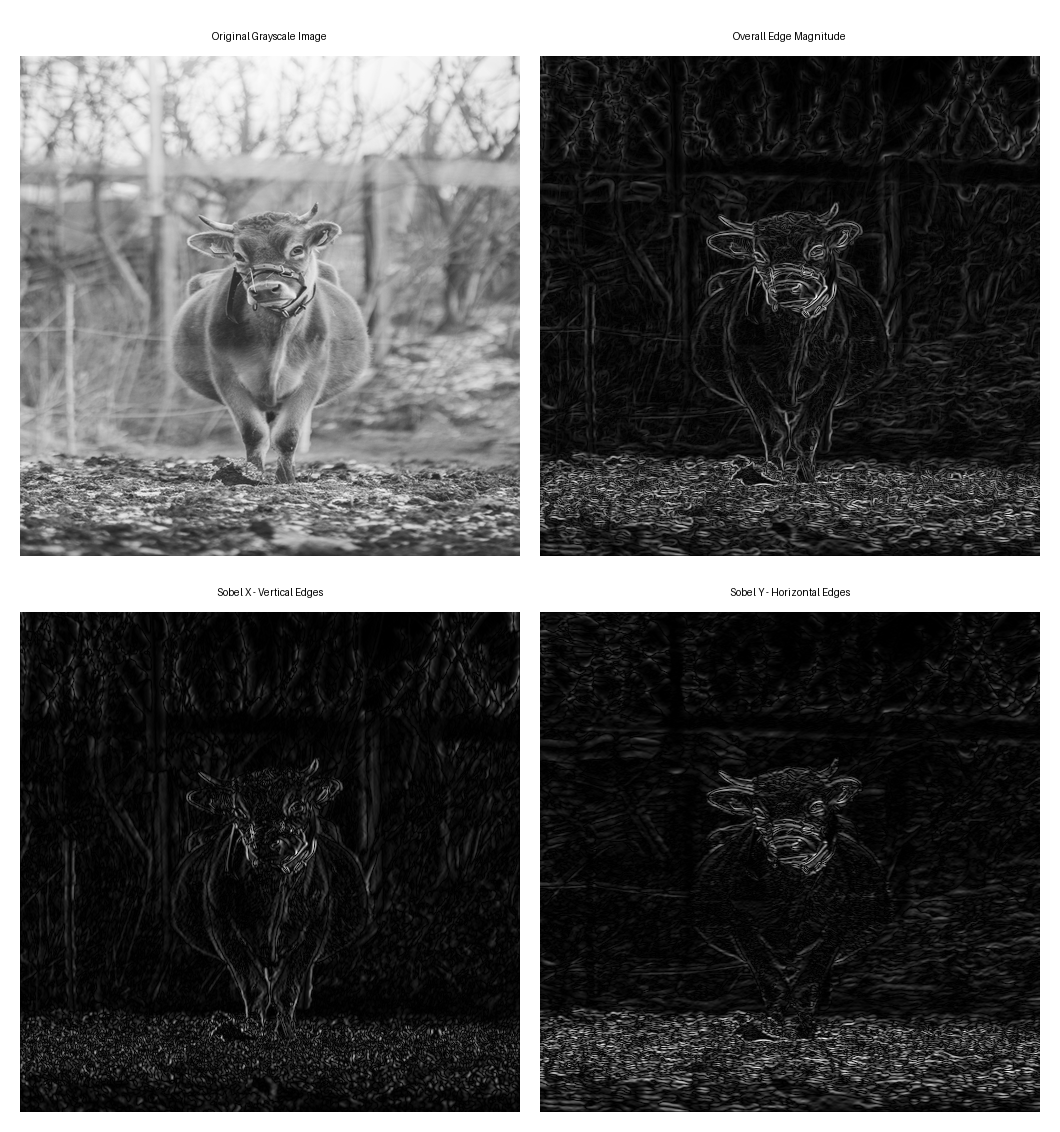

In [11]:
positions = [
    (padding, padding),
    (tile_width + (padding * 2), padding),
    (padding, tile_height + (padding * 2)),
    (tile_width + (padding * 2), tile_height + (padding * 2)),
]

for tile, position in zip(tiles, positions):
    combined_image.paste(tile, position)

if display is not None:
    display(combined_image)
else:
    print("Combined Sobel result image created successfully.")
